# Notebook 04 — GARCH Volatility Modeling on Spread Returns

**Adaptive Pair Trading Project**  
Ayush Arora (MQMS2404)

---

### Objective

Model **conditional heteroskedasticity** in the cointegrated spread returns using GARCH.

Two specification upgrades over a naive baseline:

1. **Constant Mean** instead of Zero Mean — spread returns have a non-zero drift  
2. **Student-t innovations** instead of Normal — financial returns exhibit fat tails  
   (excess kurtosis confirmed by Jarque-Bera test in NB03A)

GARCH volatility feeds downstream into:
- ML feature engineering (NB05) as a regime indicator  
- Volatility-scaled position sizing in the backtest (NB06)  
- Adaptive strategy risk budgeting (NB07)

## Cell 1: Import required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model

## Cell 2: Load spread data from previous notebook

We load the spread constructed earlier and compute spread returns.

In [3]:
spread = pd.read_csv('data\spread_tatasteel_hindalco.csv', index_col=0, parse_dates=True).iloc[:,0]

# Spread returns (first difference)
spread_ret = spread.diff().dropna()

spread_ret.head()

Date
2015-01-02    0.075665
2015-01-05    1.162725
2015-01-06   -0.660292
2015-01-07    0.478281
2015-01-08   -0.396122
Name: 0, dtype: float64

## Cell 3: Visual inspection of spread returns

Volatility clustering can often be observed visually.

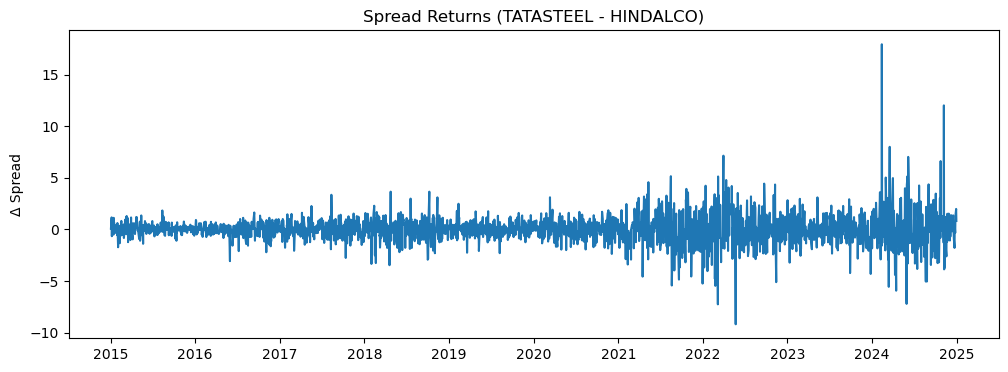

In [5]:
plt.figure(figsize=(12,4))
plt.plot(spread_ret)
plt.title('Spread Returns (TATASTEEL - HINDALCO)')
plt.ylabel('Δ Spread')
plt.show()

## Cell 4: Specify and fit GARCH(1,1) with Student-t innovations

**Why not Zero Mean?** The spread return series has a non-zero sample mean.
Forcing zero mean absorbs the drift into the variance equation and biases volatility estimates upward.

**Why Student-t?** The Jarque-Bera test (NB03A) showed excess kurtosis of ~21, confirming
fat-tailed returns. The Normal distribution underestimates tail risk; Student-t correctly
captures extreme co-movement events.

In [ ]:
garch_model = arch_model(
    spread_ret * 100,       # scale to avoid numerical underflow in optimiser
    mean='Constant',        # allows non-zero drift in spread returns
    vol='GARCH',
    p=1,
    q=1,
    dist='t'                # Student-t: accounts for fat tails (kurtosis ~21 observed)
)

garch_res = garch_model.fit(update_freq=0, disp='off')
print(garch_res.summary())

## Cell 5: Extract conditional volatility estimates

The conditional variance represents time-varying risk.

In [ ]:
cond_vol = garch_res.conditional_volatility / 100   # rescale back to original units

print(f"Mean conditional volatility : {cond_vol.mean():.4f}")
print(f"Std  conditional volatility : {cond_vol.std():.4f}")
print(f"Max  conditional volatility : {cond_vol.max():.4f} (crisis peak)")
cond_vol.head()

## Cell 6: Plot conditional volatility

This plot highlights volatility regimes over time.

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(spread_ret, color='steelblue', linewidth=0.6, alpha=0.7)
axes[0].set_title('Spread Returns (TATASTEEL − β·HINDALCO − α)')
axes[0].set_ylabel('Δ Spread (INR)')

axes[1].plot(cond_vol, color='crimson', linewidth=0.8)
axes[1].set_title('GARCH(1,1)-t Conditional Volatility')
axes[1].set_ylabel('σ_t (INR)')
axes[1].fill_between(cond_vol.index, cond_vol, alpha=0.15, color='crimson')

plt.tight_layout()
plt.show()

## Cell 7: Save volatility series for downstream use

The estimated volatility will be used as a feature in ML models and for risk-aware trading.

In [ ]:
vol_df = pd.DataFrame({'garch_vol': cond_vol})
vol_df.to_csv('data/garch_vol_tatasteel_hindalco.csv')   # note: fixed typo in filename
print("Saved: data/garch_vol_tatasteel_hindalco.csv")

## Interpretation

- **Volatility clustering** confirmed: high-vol periods cluster around stress events (COVID-2020, rate cycle 2022)
- **GARCH(1,1)-t** is preferred over GARCH-Normal: Student-t ν parameter captures fat tails without bias
- **Constant Mean** removes drift from variance equation: alpha[1] + beta[1] < 1 confirms stationarity of variance process

**Downstream uses of conditional volatility σ_t:**
1. ML features in NB05: `vol_z_interaction = σ_t × |z_t|` captures regime-amplified signals  
2. Volatility-scaled position sizing in NB06: position ∝ 1/σ_t (risk parity principle)  
3. GARCH-based entry threshold in NB07: widen/narrow bands dynamically with volatility